In [2]:
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
import pandas as pd
import os

In [ ]:
# mississippi data
# scenario 1 : linear probing and fine tuning with a single decoder layer


11


(0.4079736983680823, 0.778947148892761)

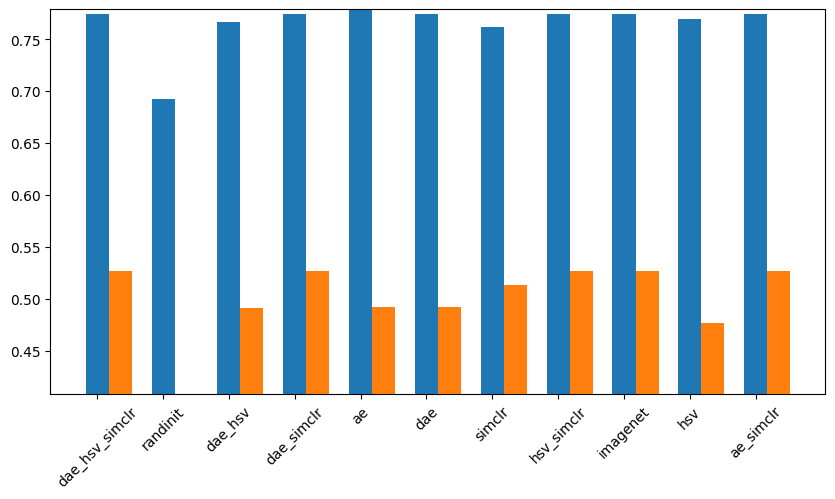

In [54]:
# scenario 2: linear probing and fine tuning with a complex decoder
logs_dir = '/Volumes/dhester_ssd/mslc_pretraining_ft_results_20250112/hrnet_w18/'

test_metrics_paths = glob(os.path.join(logs_dir, '*', '*', 'test_metrics.csv'))
df_list = []

for test_metrics_path in test_metrics_paths:
    weights = test_metrics_path.split('/')[-3]
    n_layers_unfrozen = int(test_metrics_path.split('/')[-2])
    df = pd.read_csv(test_metrics_path)
    df['weights'] = weights
    df['n_layers_unfrozen'] = n_layers_unfrozen
    df_list.append(df)
test_metrics_total_df = pd.concat(df_list)

max_n_layers_unfrozen = test_metrics_total_df.groupby('n_layers_unfrozen').count().max().values[0]
print(max_n_layers_unfrozen, )

# find models with n_layers_unfrozen == max_n_layers_unfrozen
test_metrics_reduced_df = test_metrics_total_df[test_metrics_total_df['n_layers_unfrozen'].isin([0, 1, max_n_layers_unfrozen])]
test_metrics_reduced_df

# linear probing plots (n_layers frozen == 0)
# use multi-bar graph to plot f1 score and macro f1 score
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
bar_width = 0.35
bar_positions = np.arange(len(test_metrics_reduced_df['weights'].unique())) - bar_width / 2

ax.xaxis.set_ticks(bar_positions)
ax.xaxis.set_ticklabels(test_metrics_reduced_df['weights'].unique(), rotation=45)
for i in range(2):
    if i == 0:
        ax.bar(bar_positions + i * bar_width, test_metrics_reduced_df[test_metrics_reduced_df['n_layers_unfrozen'] == 0]['f1_score'], bar_width, label='f1_score')
    else:
        ax.bar(bar_positions + i * bar_width, test_metrics_reduced_df[test_metrics_reduced_df['n_layers_unfrozen'] == 0]['macro_f1_score'], bar_width, label='macro_f1_score')

min_macro_f1_score = test_metrics_reduced_df[test_metrics_reduced_df['n_layers_unfrozen'] == 0]['macro_f1_score'].min().min()
max_f1_score = test_metrics_reduced_df[test_metrics_reduced_df['n_layers_unfrozen'] == 0]['f1_score'].max().max()
ax.set_ylim(min_macro_f1_score, max_f1_score)

In [59]:
## scenario 2 - only training a complex decoder

test_metrics_reduced_2_df = test_metrics_total_df[test_metrics_total_df['n_layers_unfrozen'] == 1]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
bar_width = 0.35
bar_positions = np.arange(len(test_metrics_reduced_df['weights'].unique())) - bar_width / 2

ax.xaxis.set_ticks(bar_positions)
ax.xaxis.set_ticklabels(test_metrics_reduced_df['weights'].unique(), rotation=45)
for i in range(2):
    if i == 0:
        ax.bar(bar_positions + i * bar_width, test_metrics_reduced_2_df['f1_score'], bar_width, label='f1_score')
    else:
        ax.bar(bar_positions + i * bar_width, test_metrics_reduced_2_df['macro_f1_score'], bar_width, label='macro_f1_score')

min_macro_f1_score = test_metrics_reduced_2_df['macro_f1_score'].min().min()
max_f1_score = test_metrics_reduced_2_df['f1_score'].max().max()
ax.set_ylim(min_macro_f1_score, max_f1_score)

# add bar for imagenet erghts f1 and macro f1 such that one can compare the performance of the model with the imagenet weights
ax.hlines(test_metrics_reduced_2_df[test_metrics_reduced_2_df['weights'] == 'imagenet']['f1_score'], , color='0', label='imagenet f1_score')
# ax.hlines(test_metrics_reduced_2_df[test_metrics_reduced_2_df['weights'] == 'imagenet']['macro_f1_score'], -0.5, 0.5, color='r', label='imagenet macro_f1_score')

SyntaxError: invalid syntax (343291531.py, line 22)